# Titanic Dataset - Data Cleaning & Visualization

## Machine Learning Fundamentals - Week 1 (Task 2)

### Objective

In this notebook, we will clean the Titanic dataset by handling missing values, identify outliers, and visualize important patterns using different charts. This helps us understand the data before building any machine learning model.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

In [16]:
df = pd.read_csv("train.csv")

In [17]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [18]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Handling Missing Values

The **Cabin** column contains a large number of missing values (more than 75%), so it will be removed because filling such a large amount of missing data would not be reliable.

The **Age** column has some missing values, which will be filled using the median because age is a numerical feature and the median is less affected by outliers.

The **Embarked** column has only a few missing values, so they will be filled with the most frequent value (mode).

In [19]:
df = df.drop(columns=["Cabin"])
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [20]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

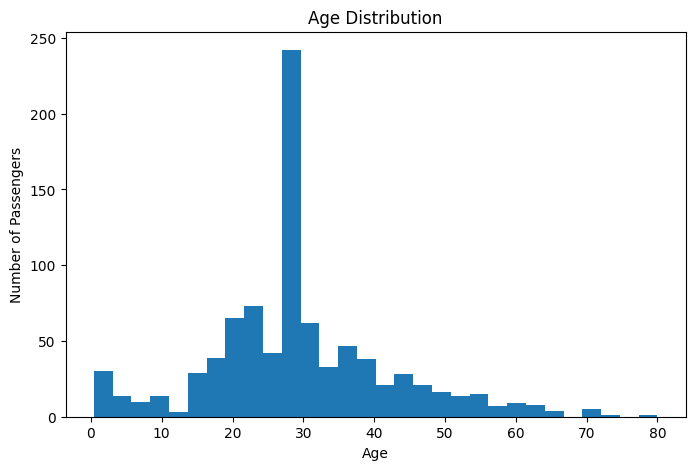

In [21]:
# Histogram

plt.figure(figsize=(8,5))
plt.hist(df["Age"], bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

### Observation

Most passengers were between 20 and 40 years old. The distribution is slightly right-skewed, with fewer elderly passengers.

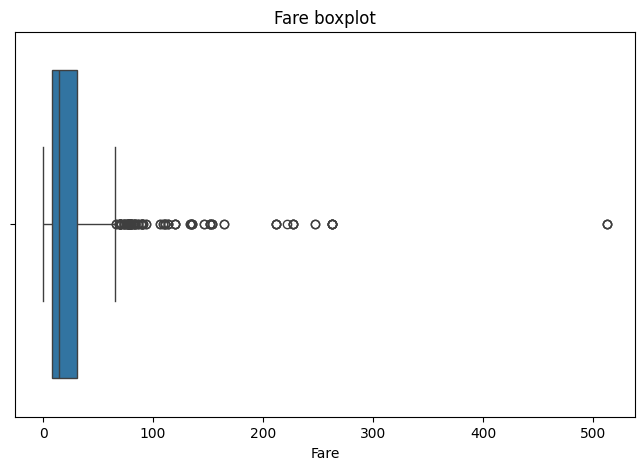

In [22]:
# Boxplot (Detecting Outliers)

plt.figure(figsize=(8,5))
sns.boxplot(x=df["Fare"])
plt.title("Fare boxplot")

plt.show()

### Observation

The Fare column contains several high-value outliers. These represent passengers who paid significantly higher ticket prices than the majority.

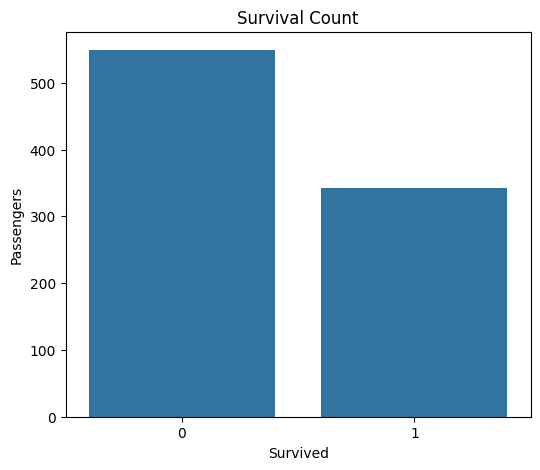

In [23]:
# Bar Chart (survival count)

plt.figure(figsize=(6,5))
sns.countplot(x="Survived", data = df)
plt.title("Survival Count")
plt.xlabel("Survived")
plt.ylabel("Passengers")

plt.show()


### Observation

More passengers did not survive than survived. This indicates that the survival rate was below 50%.

In [24]:
# Correlation Heatmap

# first select numerical columns
numeric_df = df.select_dtypes(include=np.number)



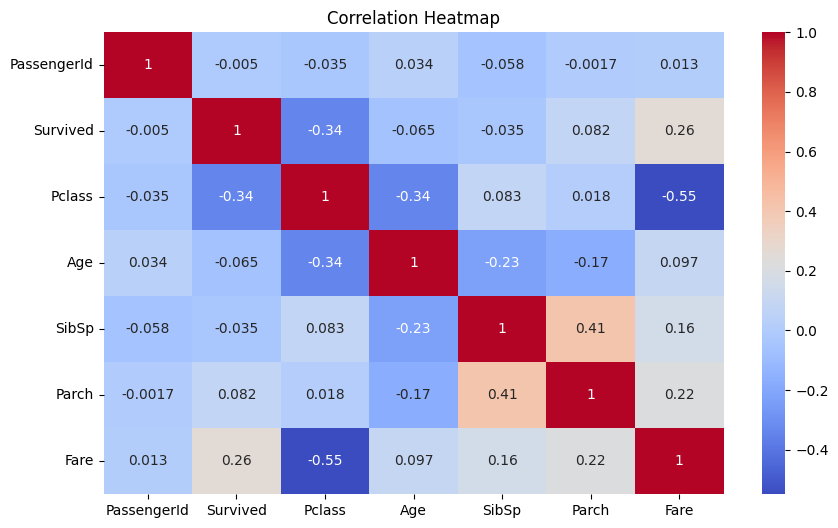

In [25]:
# Now heatmap
plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")

plt.show()


### Observation

Most numerical features have weak correlations with each other. Fare and Passenger Class show some relationship, while Survived has only moderate correlation with a few features.

# Which feature do you think most affects survival?

Among all the available features, **Sex** appears to have the strongest impact on survival. Female passengers survived at a much higher rate than male passengers because of the evacuation policy followed during the disaster ("women and children first").

Passenger Class (Pclass) also plays an important role since first-class passengers generally had better access to lifeboats. Age has some influence, especially for children, but its impact is smaller compared to Sex and Passenger Class.

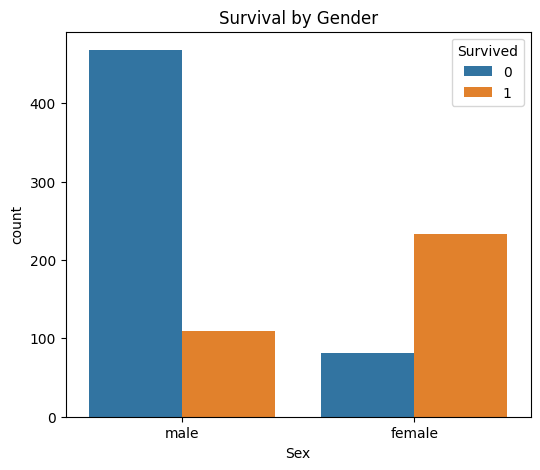

In [26]:
# Survival By Gender
plt.figure(figsize=(6,5))
sns.countplot(x="Sex", hue="Survived", data=df)
plt.title("Survival by Gender")

plt.show()